In [1]:
import pandas as pd
from IPython.display import Audio, display
import soundfile as sf
from pydub import AudioSegment
import numpy as np
import os, gc , time, json
from io import BytesIO


AudioPATH= "./audio"
RefVoicePATH = "./audio/ref_voice/warm_reporter_well_paced_steady_friendly.mp3"
RefVoicePATHWav = "./audio/ref_voice/warm_reporter_well_paced_steady_friendly.wav"
TokenModel="Qwen/Qwen3-TTS-Tokenizer-12Hz"
ModelId1="Qwen/Qwen3-TTS-12Hz-1.7B-Base"
ModelId2="Qwen/Qwen3-TTS-12Hz-0.6B-Base"
ModelId3="Qwen3-TTS-12Hz-0.6B-CustomVoice"

In [2]:
# !pip install pydub

In [3]:
## Convert refvoice  mp3 file to wave file

In [4]:
from pydub import AudioSegment

# Define the paths for the input MP3 and output WAV files
src = RefVoicePATH
dst = RefVoicePATHWav

# Convert the MP3 file to a WAV file
try:
    sound = AudioSegment.from_mp3(src)
    sound.export(dst, format="wav")
    print(f"Successfully converted {src} to {dst}")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully converted ./audio/ref_voice/warm_reporter_well_paced_steady_friendly.mp3 to ./audio/ref_voice/warm_reporter_well_paced_steady_friendly.wav


## Load Cantonese dataset, download from huggingface : a cleaned verison from AlienKevin/mixed_cantonese_and_english_speech:
https://huggingface.co/datasets/AlienKevin/mixed_cantonese_and_english_speech

In [5]:
df = pd.read_parquet("train-00000-of-00001.parquet")

In [6]:
df.columns

Index(['audio', 'sentence', 'topic'], dtype='object')

In [7]:
df

,audio,sentence,topic
0,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！,天氣
1,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。,天氣
2,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。,天氣
3,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...,天氣
4,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Forecast話晚上嘅weather會變得好cold，會降到freezing point，...,天氣
...,...,...,...
14012,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,雖然香港天氣好hot，但我哋可以想下use less air con，改用風扇。,环境
14013,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Buy local 嘅商品都可以減少carbon footprint，唔再郵寄長途嘅貨品。,环境
14014,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,用solar power同wind power都唔錯，我哋要追求sustainable嘅生活方式。,环境
14015,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,"Reduce, Reuse, Recycle 呢個三R原則喺日常生活中實踐，即係好好嘅典範。",环境


In [8]:
df["audio"][0]

{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x00\x00\x00\x0f\x00\x00\x03Lavf58.76.100\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xf3X\xc0\x00\x00\x00\x00\x00\x00\x00\x00\x00Info\x00\x00\x00\x0f\x00\x00\x00\xe4\x00\x00`\xe4\x00\x05\x07\t\r\x0f\x11\x13\x17\x19\x1b\x1e!#%(+-0257:<?BDFILNPSVX[^`behjlprtvz|~\x82\x84\x86\x88\x8c\x8e\x90\x92\x96\x98\x9a\x9d\xa0\xa2\xa4\xa7\xaa\xac\xaf\xb1\xb4\xb6\xb9\xbc\xbe\xc1\xc3\xc6\xc8\xcb\xcd\xd0\xd2\xd5\xd7\xda\xdd\xdf\xe1\xe4\xe7\xe9\xeb\xef\xf1\xf3\xf5\xf9\xfb\xfd\x00\x00\x00\x00Lavc58.13\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00$\x04\x15\x00\x00\x00\x00\x00\x00`\xe4\xc0zi\x0b\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xf38\xc4\x00\x00\x00\x03H\x00\x00\x00\x00LAME3.100UUUUUUUUUUUUUUUUUUUUULAME3.100UUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUU\xff\xf38\xc4_\x00\x00\x03H\x00\x00\x00\x00UUUUUUUUUUUUUUUUUUUUUUUUUUUUUULAME3.100UUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUU\xff\xf38\xc4\xa0\x00\x00\x03H\x00\x00\x00\x00U

In [9]:
df["topic"].unique()

array(['天氣', '食物', '旅遊', '娛樂', '體育', '本地時事', '購物', '學習', '工作', '健康同健身',
       '宠物', '科技同新闻', '电影同电视剧', '音乐同艺术', '爱好同兴趣', '历史同文学', '社交媒体同网络文化',
       '环境'], dtype=object)

## Checking the Audio and Text label

In [10]:
def playAudio(raw):
    display(Audio(raw))

In [11]:
index = 1

playAudio(df["audio"][index]["bytes"]) 
print(f"Index : {index}")
print(f"Text : {df["sentence"][index]}")
print(f"File: {df["audio"][index]["path"]}")

Index : 1
Text : 我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。
File: 1_2.mp3


## Prepare Audio File for Hong Kong Cantonese (Fine tune) Training Dataset

In [12]:
def generateAudioFile(raw : bytes, fileName: str, format_hint="mp3"):
    # Wrap bytes in memory buffer
    audio_buffer = BytesIO(raw)
    # Try to load (pydub guesses format from content or you can force it)
    # audio = AudioSegment.from_file(audio_buffer, format=format_hint)
    data, samplerate = sf.read(audio_buffer)
    # print(samplerate)
    # Write to new file (format guessed from extension)
    sf.write(fileName, data, samplerate)
    
    print(f"Saved via soundfile → {fileName}")
    
    

In [13]:
generateAudioFile(df["audio"][index]["bytes"], f"{AudioPATH}/{index}.wav")

Saved via soundfile → ./audio/1.wav


In [14]:
numberSample= 2000 #500
for idx in range(numberSample):
    generateAudioFile(df["audio"][idx]["bytes"], f"{AudioPATH}/{idx}.wav")

Saved via soundfile → ./audio/0.wav
Saved via soundfile → ./audio/1.wav
Saved via soundfile → ./audio/2.wav
Saved via soundfile → ./audio/3.wav
Saved via soundfile → ./audio/4.wav
Saved via soundfile → ./audio/5.wav
Saved via soundfile → ./audio/6.wav
Saved via soundfile → ./audio/7.wav
Saved via soundfile → ./audio/8.wav
Saved via soundfile → ./audio/9.wav
Saved via soundfile → ./audio/10.wav
Saved via soundfile → ./audio/11.wav
Saved via soundfile → ./audio/12.wav
Saved via soundfile → ./audio/13.wav
Saved via soundfile → ./audio/14.wav
Saved via soundfile → ./audio/15.wav
Saved via soundfile → ./audio/16.wav
Saved via soundfile → ./audio/17.wav
Saved via soundfile → ./audio/18.wav
Saved via soundfile → ./audio/19.wav
Saved via soundfile → ./audio/20.wav
Saved via soundfile → ./audio/21.wav
Saved via soundfile → ./audio/22.wav
Saved via soundfile → ./audio/23.wav
Saved via soundfile → ./audio/24.wav
Saved via soundfile → ./audio/25.wav
Saved via soundfile → ./audio/26.wav
Saved via s

In [15]:
## Random pick train audio for reference audio

In [16]:
import random

# Generate a random integer between 1 and 10 (inclusive)
random_integer = random.randint(1, numberSample)
print(random_integer)

1575


In [17]:
generateAudioFile(df["audio"][random_integer]["bytes"], f"{AudioPATH}/ref_voice/alienkevin.wav")

Saved via soundfile → ./audio/ref_voice/alienkevin.wav


### Resample ALL Audio file Qwen3 TTS requirement only support 24Khz

In [18]:
import librosa
import soundfile as sf

# wav, sr = librosa.load(f"{AudioPATH}/2.wav", sr=None)
# wav, sr = librosa.load(RefVoicePATHWav, sr=None)
wav , sr = librosa.load(f"{AudioPATH}/ref_voice/alienkevin.wav", sr=None)
print(f"Original Sample rate: {sr}")

if sr != 24000:
    newWav = librosa.resample(wav, orig_sr=sr, target_sr=24000)
    sf.write(f"{AudioPATH}/ref_voice/alienkevin.wav", newWav, 24000)
    # print(f"New Sample rate: {tempSR}")
    sr = 24000
# else:
#     print("

/media/johnsonhk88/Big-Data-Disk7/venv-qwen3tts/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original Sample rate: 16000


In [19]:
def batchResample(audioPath, targetSR=24000):
    wav, sr = librosa.load(audioPath, sr=None)
    if sr != 24000:
        newWav = librosa.resample(wav, orig_sr=sr, target_sr=24000)
        sf.write(audioPath, newWav, targetSR)
        print(f"Saved resample soundfile → {audioPath}")
    else:
        print(f"Audio File ready support target sample rate: {targetSR}")
    

In [20]:
# numberSample= 500
for idx in range(numberSample):
    batchResample(f"{AudioPATH}/{idx}.wav", targetSR=24000)

Saved resample soundfile → ./audio/0.wav
Saved resample soundfile → ./audio/1.wav
Saved resample soundfile → ./audio/2.wav
Saved resample soundfile → ./audio/3.wav
Saved resample soundfile → ./audio/4.wav
Saved resample soundfile → ./audio/5.wav
Saved resample soundfile → ./audio/6.wav
Saved resample soundfile → ./audio/7.wav
Saved resample soundfile → ./audio/8.wav
Saved resample soundfile → ./audio/9.wav
Saved resample soundfile → ./audio/10.wav
Saved resample soundfile → ./audio/11.wav
Saved resample soundfile → ./audio/12.wav
Saved resample soundfile → ./audio/13.wav
Saved resample soundfile → ./audio/14.wav
Saved resample soundfile → ./audio/15.wav
Saved resample soundfile → ./audio/16.wav
Saved resample soundfile → ./audio/17.wav
Saved resample soundfile → ./audio/18.wav
Saved resample soundfile → ./audio/19.wav
Saved resample soundfile → ./audio/20.wav
Saved resample soundfile → ./audio/21.wav
Saved resample soundfile → ./audio/22.wav
Saved resample soundfile → ./audio/23.wav
Sa

In [21]:
# extract Dataframe

In [22]:
selectedDF =df[:numberSample].copy()

In [23]:
selectedDF

,audio,sentence,topic
0,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！,天氣
1,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。,天氣
2,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。,天氣
3,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...,天氣
4,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Forecast話晚上嘅weather會變得好cold，會降到freezing point，...,天氣
...,...,...,...
1995,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,你嘅work attitude十分影响你嘅career development，要常常che...,工作
1996,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,有時候，唔係要work harder，而係要work smarter。,工作
1997,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Job satisfaction同money唔一定要相反，有時你最享受嘅work可能就係你最赚嘅。,工作
1998,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,睇得太远可能會miss住身邊嘅opportunity，即使個目标未到，都要appreciat...,工作


### Generate JSONL file for prepare Training data

In [24]:
def generateJSONFile(dataFrame, audioDirectory, refAudioPath, outputFile="train.jsonl"):
    with open(outputFile, "w", encoding="utf-8") as f:
        for i, row in dataFrame.iterrows():
            obj = {
                "audio": f"{audioDirectory}/{i}.wav",
                "text": row["sentence"],   # map sentence -> text
                "ref_audio": refAudioPath,
            }
            # ensure_ascii=False keeps Chinese characters, etc.
            f.write(json.dumps(obj, ensure_ascii=False) + "\n")

In [25]:
# generateJSONFile(selectedDF, AudioPATH, RefVoicePATHWav, outputFile="train_raw.jsonl")
generateJSONFile(selectedDF, AudioPATH, f"{AudioPATH}/ref_voice/alienkevin.wav", 
                 outputFile="train_raw.jsonl")

In [26]:
trainDF = pd.read_json("train_raw.jsonl", lines=True)

print(trainDF.head())
print(trainDF.columns)  # Should show: ['audio', 'text', 'ref_audio']

           audio                                               text  \
0  ./audio/0.wav        你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！   
1  ./audio/1.wav         我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。   
2  ./audio/2.wav         飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。   
3  ./audio/3.wav  周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...   
4  ./audio/4.wav  Forecast話晚上嘅weather會變得好cold，會降到freezing point，...   

                          ref_audio  
0  ./audio/ref_voice/alienkevin.wav  
1  ./audio/ref_voice/alienkevin.wav  
2  ./audio/ref_voice/alienkevin.wav  
3  ./audio/ref_voice/alienkevin.wav  
4  ./audio/ref_voice/alienkevin.wav  
Index(['audio', 'text', 'ref_audio'], dtype='object')


In [27]:
trainDF

,audio,text,ref_audio
0,./audio/0.wav,你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！,./audio/ref_voice/alienkevin.wav
1,./audio/1.wav,我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。,./audio/ref_voice/alienkevin.wav
2,./audio/2.wav,飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。,./audio/ref_voice/alienkevin.wav
3,./audio/3.wav,周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...,./audio/ref_voice/alienkevin.wav
4,./audio/4.wav,Forecast話晚上嘅weather會變得好cold，會降到freezing point，...,./audio/ref_voice/alienkevin.wav
...,...,...,...
1995,./audio/1995.wav,你嘅work attitude十分影响你嘅career development，要常常che...,./audio/ref_voice/alienkevin.wav
1996,./audio/1996.wav,有時候，唔係要work harder，而係要work smarter。,./audio/ref_voice/alienkevin.wav
1997,./audio/1997.wav,Job satisfaction同money唔一定要相反，有時你最享受嘅work可能就係你最赚嘅。,./audio/ref_voice/alienkevin.wav
1998,./audio/1998.wav,睇得太远可能會miss住身邊嘅opportunity，即使個目标未到，都要appreciat...,./audio/ref_voice/alienkevin.wav


In [28]:
trainDF["ref_audio"][0]

'./audio/ref_voice/alienkevin.wav'

### # Download model into local Directory

In [29]:
# Using huggingface-cli (install if needed: pip install -U huggingface_hub[cli])

!huggingface-cli download Qwen/Qwen3-TTS-12Hz-0.6B-Base --local-dir ./Qwen3-TTS-12Hz-0.6B-Base
# !huggingface-cli download Qwen/Qwen3-TTS-12Hz-0.6B-CustomVoice --local-dir ./Qwen3-TTS-12Hz-0.6B-CustomVoice

⚠️  Warning: 'huggingface-cli download' is deprecated. Use 'hf download' instead.
Fetching 13 files: 100%|██████████████████████| 13/13 [00:00<00:00, 2433.00it/s]
/media/johnsonhk88/Big-Data-Disk7/qwen3-tts-hk-cantonese-finetune/Dataset-Cantonese-Training/Qwen3-TTS-12Hz-0.6B-Base


# Run Prepare data script from Qwen3 fine turning python script)

In [30]:
%%time
!python prepare_data.py \
  --device cuda:0 \
  --tokenizer_model_path Qwen/Qwen3-TTS-Tokenizer-12Hz \
  --input_jsonl train_raw.jsonl \
  --output_jsonl train_with_codes.jsonl

CPU times: user 162 ms, sys: 21.3 ms, total: 184 ms
Wall time: 28.1 s


# Run SFT using the prepared JSONL:
#### select batch size depend on your gpu memory: minimize at least GPU 12GB VRAM, otherwise error Out-of-Memory (OOM)
#### batch _size =1 or 2 for 12GB (3080 GPU),  batch_size =4 for 16GB GPU VRAM

In [70]:
# %%time
# !python sft_12hz.py \
#   --init_model_path ./Qwen3-TTS-12Hz-0.6B-Base \
#   --output_model_path output \
#   --train_jsonl train_with_codes.jsonl \
#   --batch_size 1 \
#   --lr 2e-6 \
#   --num_epochs 10 \
#   --speaker_name speaker_test

# not support fine tuning 
# !python sft_12hz.py \  
#   --init_model_path ./Qwen3-TTS-12Hz-0.6B-CustomVoice \
#   --output_model_path output \
#   --train_jsonl train_with_codes.jsonl \
#   --batch_size 2 \
#   --lr 2e-6 \
#   --num_epochs 10 \
#   --speaker_name speaker_test

### MLflow Trace support version

In [36]:
%%time
!python sft_12hz_mlflow.py \
  --init_model_path ./Qwen3-TTS-12Hz-0.6B-Base \
  --output_model_path output \
  --train_jsonl train_with_codes.jsonl \
  --batch_size 1 \
  --lr 2e-6 \
  --num_epochs 10 \
  --speaker_name speaker_test \
  --mlflow_tracking_uri http://localhost:5000 


Using MLflow tracking URI: http://localhost:5000
`torch_dtype` is deprecated! Use `dtype` instead!

=== Starting Epoch 0 ===
Epoch 0 | Step 0 | Loss: 12.4028
Epoch 0 | Step 10 | Loss: 12.8135
Epoch 0 | Step 20 | Loss: 13.9305
Epoch 0 | Step 30 | Loss: 12.0342
Epoch 0 | Step 40 | Loss: 12.8137
Epoch 0 | Step 50 | Loss: 14.0065
Epoch 0 | Step 60 | Loss: 10.9497
Epoch 0 | Step 70 | Loss: 11.5266
Epoch 0 | Step 80 | Loss: 12.3629
Epoch 0 | Step 90 | Loss: 12.4055
Epoch 0 | Step 100 | Loss: 11.6651
Epoch 0 | Step 110 | Loss: 10.8181
Epoch 0 | Step 120 | Loss: 12.0519
Epoch 0 | Step 130 | Loss: 11.7884
Epoch 0 | Step 140 | Loss: 12.3777
Epoch 0 | Step 150 | Loss: 11.5299
Epoch 0 | Step 160 | Loss: 11.7905
Epoch 0 | Step 170 | Loss: 11.9757
Epoch 0 | Step 180 | Loss: 10.9087
Epoch 0 | Step 190 | Loss: 10.1952
Epoch 0 | Step 200 | Loss: 11.1651
Epoch 0 | Step 210 | Loss: 11.6829
Epoch 0 | Step 220 | Loss: 11.1364
Epoch 0 | Step 230 | Loss: 11.8506
Epoch 0 | Step 240 | Loss: 12.9184
Epoch 0 | S

## MLflow Log Chart
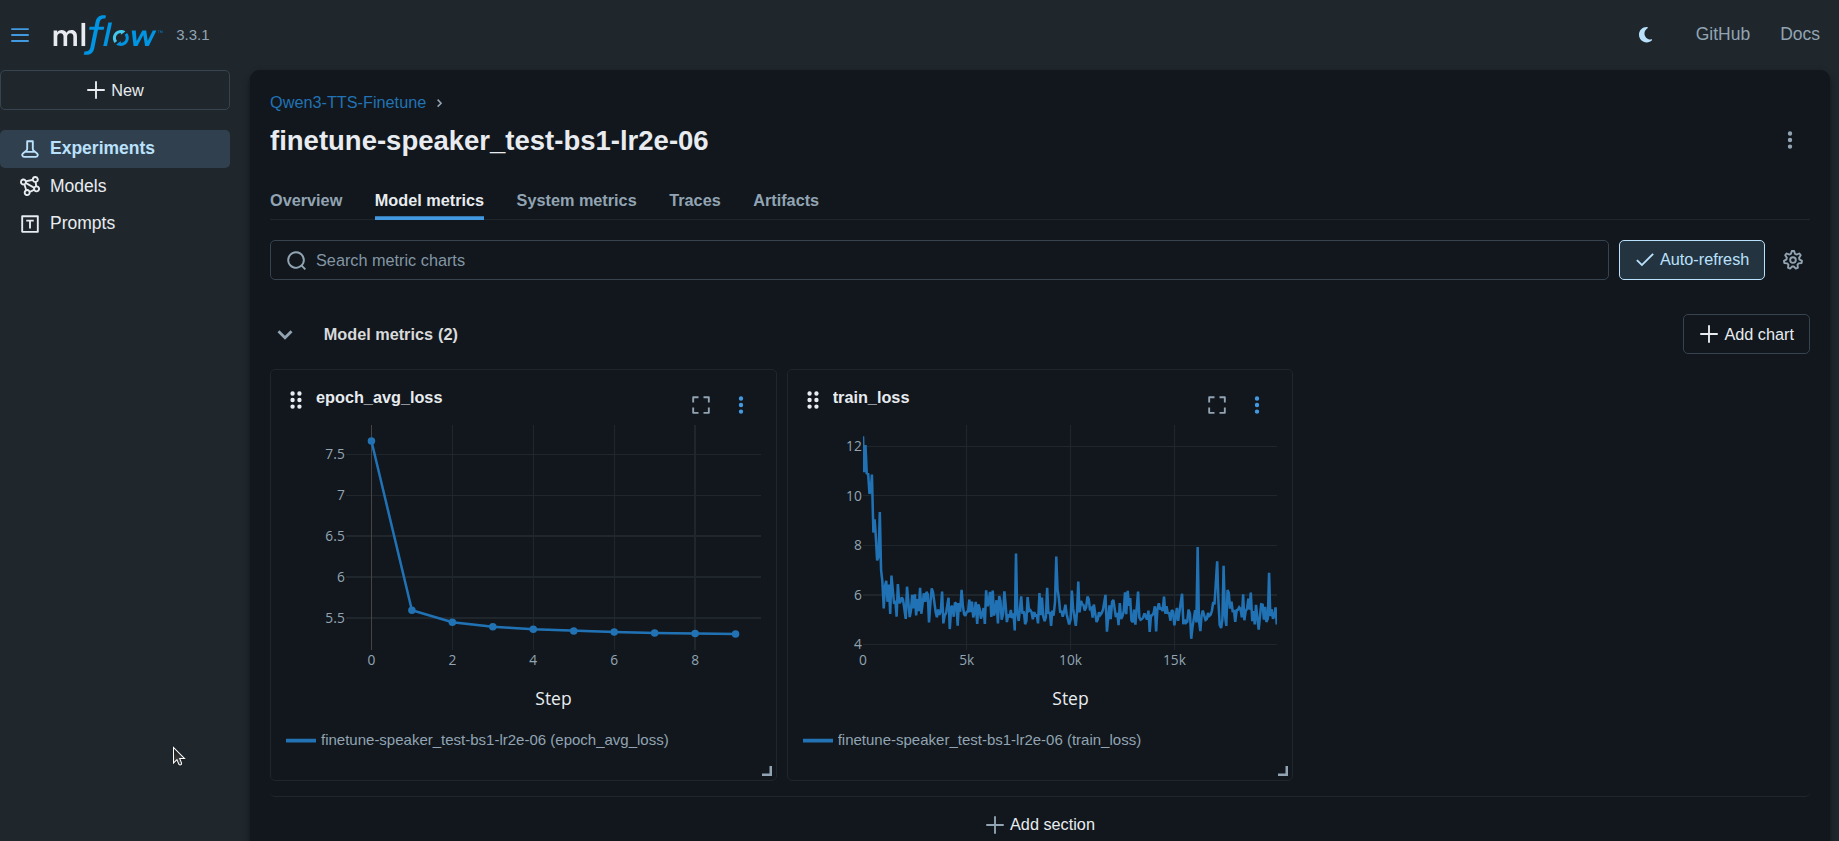

In [38]:
# upload final model to mlflow
import mlflow
# mlflow.log_artifacts("output/checkpoint-epoch-3", artifact_path="final_checkpoint")


## Test fine tuning

In [46]:
import torch
import soundfile as sf
from qwen_tts import Qwen3TTSModel

device = "cuda:0"
tts = Qwen3TTSModel.from_pretrained(
    "./output/checkpoint-epoch-9",
    device_map=device,
    dtype=torch.bfloat16,
    # attn_implementation="flash_attention_2",
    attn_implementation= "sdpa", # no flash attention 
    
)



In [47]:
tts

In [48]:
%%time
wavs, sr = tts.generate_custom_voice(
       text="其實我真係有發覺，我係一個特別善於觀察別人情緒嘅人。",
       speaker="speaker_test",
  
      # 2. Use the base Chinese language token
      language="chinese", 
       
      max_new_tokens=1500,    
      temperature=0.7,        
      top_p=0.9,
      top_k=50,
      
      # 3. CRITICAL: Disabled repetition penalty (Set to 1.0)
      repetition_penalty=1.0, 
      do_sample=True,
    
    # Optional but often helps quality
    instruct="用自然的香港粤语语气说",  # if you want style control
    # instruct="用特别愤怒的语气说", # Omit if not needed.
)
sf.write("output_custom_voice.wav", wavs[0], sr)

Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.


CPU times: user 1min 22s, sys: 200 ms, total: 1min 22s
Wall time: 1min 22s


In [38]:
# %%time
# wavs, sr = tts.generate_voice_design(
#     text="其实我真的有发现，我是一个特别善于观察别人情绪的人。",
#     # language="Auto", # Pass `Auto` (or omit) for auto language adaptive; if the target language is known, set it explicitly.
#     speaker="speaker_test",
#     # language="yue" or "zh" or "Auto",   # Try "yue" for Cantonese if supported
    
#     # === Key parameters to reduce crash & speed up ===
#     max_new_tokens=1500,        # Limit total tokens (very important for long audio)
#     temperature=0.7,            # Lower = more stable, less random crash
#     top_p=0.9,
#     top_k=50,
#     repetition_penalty=1.2,     # Helps prevent repeating patterns that cause crash
#     do_sample=True,
    
#     # Optional but often helps quality
#     instruct="用自然的香港粤语语气说",  # if you want style control
#     # instruct="用特别愤怒的语气说", # Omit if not needed.
# )
# sf.write("output_custom_voice.wav", wavs[0], sr)